# Retriever comparison on 350/50 chunks

Compare TF–IDF, `BAAI/bge-small-en-v1.5`, and BGE top-20 retrieval followed by `BAAI/bge-reranker-base`. The same 51 questions and source-level Recall@k/MRR definitions are used, excluding Q46–Q52, Q58, and Q60.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from evaluate_retrievers import run_comparison
pd.set_option('display.max_colwidth', 140)
PROJECT_ROOT

C:\Users\spide\Desktop\Project Folder - Govtech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('C:/Users/spide/Desktop/Project Folder - Govtech')

In [2]:
result = run_comparison(PROJECT_ROOT, batch_size=32)
result['run_info']

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6745.27it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:  50%|█████     | 1/2 [00:00<00:00,  3.11it/s]

Batches: 100%|██████████| 2/2 [00:00<00:00,  4.91it/s]

...

C:\Users\spide\Desktop\Project Folder - Govtech\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\spide\.cache\huggingface\hub\models--BAAI--bge-reranker-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7650.64it/s]

C:\Users\spide\Desktop\Project Folder - Govtech\evaluate_retrievers.py:146: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  "dense_embedding_dimension": dense_model.get_sentence_embedding_dimension(),


{'workbook_rows': 60,
 'excluded_rows': 9,
 'remaining_rows': 51,
 'scored_rows': 51,
 'unscored_rows': 0,
 'corpus': '350 words / 50 overlap',
 'chunks': 280,
 'dense_model': 'BAAI/bge-small-en-v1.5',
 'reranker_model': 'BAAI/bge-reranker-base',
 'query_prefix': 'Represent this sentence for searching relevant passages: ',
 'candidate_k': 20,
 'batch_size': 32,
 'dense_embedding_dimension': 384,
 'dense_max_sequence_length': 512,
 'normalized_dense_embeddings': True}

## Retrieval metrics

In [3]:
summary = result['summary']
summary.style.format('{:.3f}').highlight_max(axis=0, color='#c6efce')

,recall@1,recall@3,recall@5,mrr
method,,,,
BGE,0.553,0.734,0.803,0.802
BGE + reranker,0.530,0.694,0.737,0.787
TF-IDF,0.441,0.632,0.805,0.703


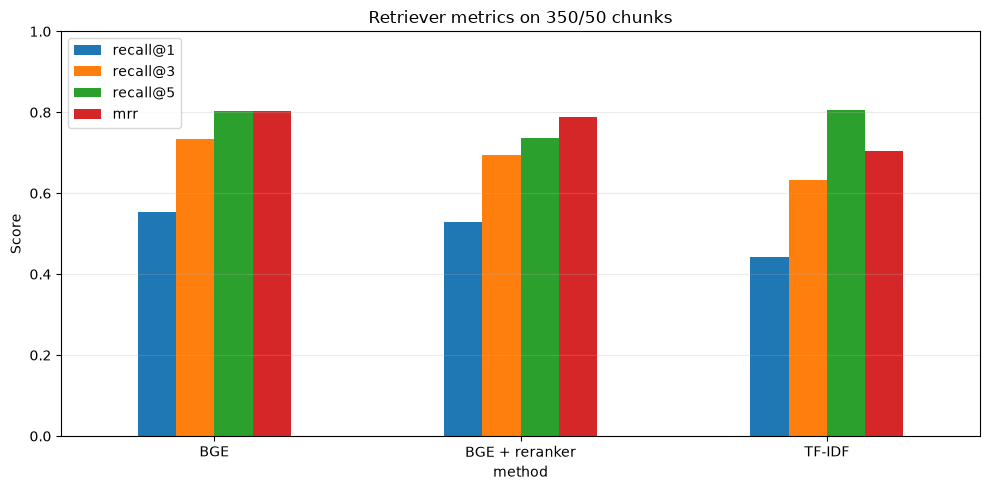

In [4]:
ax = summary.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), rot=0)
ax.set_title('Retriever metrics on 350/50 chunks')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()

## Diversification diagnostics

`unique_sources@5` should be interpreted alongside recall: diversity is useful only when it promotes relevant sources. A `diversification_candidate` has a missing gold source available in the top-20 pool while at least 40% of top-five slots are duplicates.

In [5]:
result['diversity'].round(3)

,unique_sources@5,duplicate_fraction@5,max_source_share@5,candidate_recall@20,diversification_candidate
method,,,,,
BGE,3.275,0.345,0.498,0.967,0.157
BGE + reranker,3.157,0.369,0.498,0.967,0.235
TF-IDF,3.235,0.353,0.486,0.946,0.137


In [6]:
result['errors']

error_type,candidate_retrieval_miss,duplicate_crowding,partial_or_missing_gold,ranking_miss,success
method,,,,,
BGE,0,8,3,4,36
BGE + reranker,0,12,1,7,31
TF-IDF,1,7,2,4,37


## Per-question error analysis

In [7]:
details = result['details']
problem_rows = details.loc[details['error_type'] != 'success'].sort_values(
    ['method', 'error_type', 'first_relevant_rank'], na_position='last')
problem_rows[['method','question_id','category','question','gold_sources','recall@5',
              'top5_sources','missing_gold_available_at_20','unique_sources@5',
              'diversification_candidate','error_type']].head(100)

,method,question_id,category,question,gold_sources,recall@5,top5_sources,missing_gold_available_at_20,unique_sources@5,diversification_candidate,error_type
70,BGE,Q20,multi_hop,A resale buyer has agreed on a price. What should happen from the OTP stage until the resale application is submitted?,"HDB11, HDB12",0.500000,"HDB12, HDB12, HDB12, HDB12, HDB12",HDB11,1,True,duplicate_crowding
77,BGE,Q27,conditional,"If a family is buying a resale flat, what must be established before EHG for Families is considered?","HDB05, HDB06",0.500000,"HDB05, HDB04, HDB04, HDB05, HDB04",HDB06,2,True,duplicate_crowding
86,BGE,Q36,partially_answerable,I am 35 and single. Exactly how much housing grant will I receive for the flat I am considering?,"HDB02, HDB03, HDB04",0.666667,"HDB03, HDB04, HDB03, HDB06, HDB03",HDB02,3,True,duplicate_crowding
62,BGE,Q12,direct_answerable,What are some of the main purposes of CPF described in CPF 101?,CPF02,0.000000,"CPF07, CPF07, CPF01, CPF07, CPF07",CPF02,2,True,duplicate_crowding
96,BGE,Q53,adversarial_misleading,"I'm 30 and single, so I can buy any HDB resale flat on my own as long as I can afford it, right?","HDB02, HDB08",0.000000,"HDB03, HDB01, HDB01, HDB01, HDB01","HDB02, HDB08",2,True,duplicate_crowding
52,BGE,Q2,direct_answerable,Can a single person buy an HDB flat alone under HDB's singles route?,HDB02,0.000000,"HDB03, HDB04, HDB03, HDB01, HDB01",HDB02,3,True,duplicate_crowding
56,BGE,Q6,direct_answerable,"What household income ceilings apply to an HDB housing loan for families, extended families and singles?",HDB08,0.000000,"HDB06, HDB01, HDB01, HDB01, HDB05",HDB08,3,True,duplicate_crowding
60,BGE,Q10,direct_answerable,How long is the Option to Purchase valid after it is granted for a resale flat?,HDB12,0.000000,"HDB02, HDB02, HDB01, HDB01, HDB01",HDB12,2,True,duplicate_crowding
93,BGE,Q43,partially_answerable,I want to buy a resale flat. Can you calculate my exact cash and CPF upfront payments from these pages alone?,"CPF03, HDB09",0.500000,"HDB09, HDB09, HDB01, HDB09, HDB09",,2,False,partial_or_missing_gold
95,BGE,Q45,partially_answerable,I am eligible to buy a flat. Does that automatically mean I will receive every CPF housing grant listed on HDB's site?,"HDB01, HDB02, HDB03, HDB05, HDB06",0.800000,"HDB01, HDB02, HDB06, HDB07, HDB05",,5,False,partial_or_missing_gold


In [8]:
details.loc[details['diversification_candidate'], [
    'method','question_id','question','gold_sources','top5_sources',
    'missing_gold_available_at_20','top5_chunk_ids'
]].sort_values(['method','question_id'])

,method,question_id,question,gold_sources,top5_sources,missing_gold_available_at_20,top5_chunk_ids
60,BGE,Q10,How long is the Option to Purchase valid after it is granted for a resale flat?,HDB12,"HDB02, HDB02, HDB01, HDB01, HDB01",HDB12,"HDB02:004:001, HDB02:009:001, HDB01:004:001, HDB01:012:001, HDB01:018:001"
62,BGE,Q12,What are some of the main purposes of CPF described in CPF 101?,CPF02,"CPF07, CPF07, CPF01, CPF07, CPF07",CPF02,"CPF07:003:000, CPF07:006:000, CPF01:000:000, CPF07:001:000, CPF07:004:000"
52,BGE,Q2,Can a single person buy an HDB flat alone under HDB's singles route?,HDB02,"HDB03, HDB04, HDB03, HDB01, HDB01",HDB02,"HDB03:000:000, HDB04:000:000, HDB03:002:003, HDB01:013:002, HDB01:025:000"
70,BGE,Q20,A resale buyer has agreed on a price. What should happen from the OTP stage until the resale application is submitted?,"HDB11, HDB12","HDB12, HDB12, HDB12, HDB12, HDB12",HDB11,"HDB12:010:000, HDB12:002:000, HDB12:003:000, HDB12:008:000, HDB12:001:000"
77,BGE,Q27,"If a family is buying a resale flat, what must be established before EHG for Families is considered?","HDB05, HDB06","HDB05, HDB04, HDB04, HDB05, HDB04",HDB06,"HDB05:000:000, HDB04:002:000, HDB04:000:000, HDB05:002:000, HDB04:002:004"
86,BGE,Q36,I am 35 and single. Exactly how much housing grant will I receive for the flat I am considering?,"HDB02, HDB03, HDB04","HDB03, HDB04, HDB03, HDB06, HDB03",HDB02,"HDB03:002:004, HDB04:000:000, HDB03:000:000, HDB06:000:000, HDB03:002:003"
96,BGE,Q53,"I'm 30 and single, so I can buy any HDB resale flat on my own as long as I can afford it, right?","HDB02, HDB08","HDB03, HDB01, HDB01, HDB01, HDB01","HDB02, HDB08","HDB03:000:000, HDB01:005:002, HDB01:019:002, HDB01:024:002, HDB01:013:002"
56,BGE,Q6,"What household income ceilings apply to an HDB housing loan for families, extended families and singles?",HDB08,"HDB06, HDB01, HDB01, HDB01, HDB05",HDB08,"HDB06:002:000, HDB01:001:000, HDB01:020:000, HDB01:009:000, HDB05:002:000"
111,BGE + reranker,Q10,How long is the Option to Purchase valid after it is granted for a resale flat?,HDB12,"HDB01, HDB01, HDB01, HDB01, HDB01",HDB12,"HDB01:004:001, HDB01:012:001, HDB01:018:001, HDB01:023:001, HDB01:030:001"
118,BGE + reranker,Q17,A family buying a resale flat wants both the main resale grant and EHG. How do these grant routes relate?,"HDB05, HDB06","HDB05, HDB05, HDB04, HDB04, HDB04",HDB06,"HDB05:005:000, HDB05:000:000, HDB04:000:000, HDB04:002:003, HDB04:002:000"


In [9]:
result['by_category'].round(3)

recall@1  recall@3  recall@5    mrr
method         category                                                   
BGE            adversarial_misleading     0.500     0.750     0.750  0.667
               conditional                0.700     0.900     0.950  0.900
               direct_answerable          0.533     0.600     0.667  0.633
               multi_hop                  0.333     0.650     0.783  0.825
               partially_answerable       0.587     0.793     0.863  0.950
               temporal                   1.000     1.000     1.000  1.000
BGE + reranker adversarial_misleading     0.500     0.875     0.875  0.708
               conditional                0.700     0.850     0.950  0.883
               direct_answerable          0.533     0.600     0.667  0.624
               multi_hop                  0.417     0.567     0.567  0.914
               partially_answerable       0.587     0.673     0.693  0.917
               temporal                   0.000     1.000     1.000  0.417
TF-IDF         adversarial_misleading     0.500     0.625     0.875  0.675
               conditional                0.550     0.650     0.750  0.737
               direct_answerable          0.533     0.667     0.867  0.646
               multi_hop                  0.333     0.467     0.700  0.793
               partially_answerable       0.267     0.757     0.807  0.691
               temporal                   0.500     0.500     1.000  0.625

In [10]:
print(f"CSV outputs: {result['output_dir']}")

CSV outputs: C:\Users\spide\Desktop\Project Folder - Govtech\data\experiments\evaluation_retrievers_350w_50o
